In [4]:
import numpy as np
import sys
sys.path.append("../")
import pandas as pd
import matplotlib.pyplot as plt
from preprocess_data import *
import seaborn as sns
from implementations import *

In [6]:
# load the train and test data 
x_train = pd.read_csv("../data/dataset_to_release/x_train.csv")
y_train = pd.read_csv("../data/dataset_to_release/y_train.csv")
x_test = pd.read_csv("../data/dataset_to_release/x_test.csv")

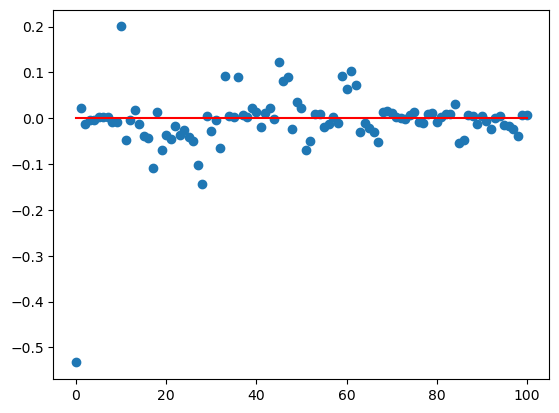

In [8]:
# plot the distribution of model parameters
w = np.load("../model_performance/model_parameters.npy")
plt.scatter(np.arange(w.shape[0]),w)
plt.plot(np.arange(w.shape[0]), np.zeros(w.shape[0]), c="r")

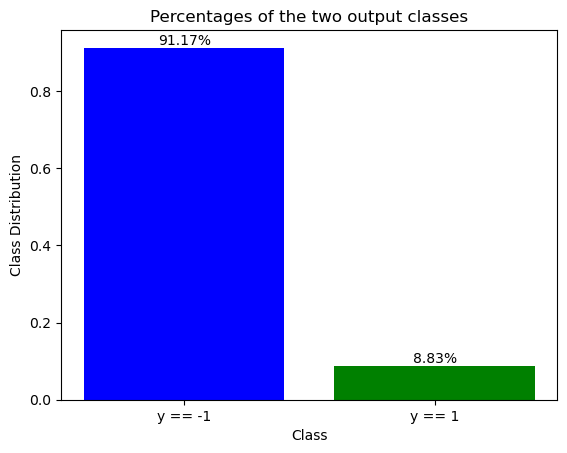

In [9]:
# calculate the percentages of the data of the two classes
class_0 = len(np.where(y_train == -1)[0])
class_1 = len(np.where(y_train == 1)[0])
percentage_class_0 = class_0 / y_train.shape[0]
percentage_class_1 = class_1 / y_train.shape[0]

# Data for the bar plot
classes = ['y == -1', 'y == 1']
percentages = [percentage_class_0, percentage_class_1]

# Create a bar plot
plt.bar(classes, percentages, color=['blue', 'green'])
plt.xlabel('Class')
plt.ylabel('Class Distribution')
plt.title('Percentages of the two output classes')

# Display the percentages on top of the bars
for i, percentage in enumerate(percentages):
    plt.text(classes[i], percentage, f'{percentage:.2%}', ha='center', va='bottom')

# Show the plot
plt.show()

In [19]:
x = np.array(x_train)

# Calculate the percentage of NaN values in each column
nan_percentage_column = np.mean(np.isnan(x), axis=0) * 100

# Calculate the percentage of NaN values in each row
nan_percentage_row = np.mean(np.isnan(x), axis=1) * 100

In [20]:
x_shape = x.shape  # Shape of your array (a, b)

# Calculate the percentage of NaN values in columns
per_25_col = (np.sum(nan_percentage_column < 25) / x_shape[1]) * 100
per_25_50_col = (np.sum((nan_percentage_column > 25) & (nan_percentage_column < 50)) / x_shape[1]) * 100
per_50_75_col = (np.sum((nan_percentage_column > 50) & (nan_percentage_column < 75)) / x_shape[1]) * 100
per_75_col = (np.sum(nan_percentage_column > 75) / x_shape[1]) * 100

# Calculate the percentage of NaN values in rows
per_25_row = (np.sum(nan_percentage_row < 25) / x_shape[0]) * 100
per_25_50_row = (np.sum((nan_percentage_row > 25) & (nan_percentage_row < 50)) / x_shape[0]) * 100
per_50_75_row = (np.sum((nan_percentage_row > 50) & (nan_percentage_row < 75)) / x_shape[0]) * 100
per_75_row = (np.sum(nan_percentage_row > 75) / x_shape[0]) * 100

# Print the percentages
print(f"Percentage of columns with less than 25% NaN values: {per_25_col:.3f}%")
print(f"Percentage of columns with NaN values between 25% and 50%: {per_25_50_col:.3f}%")
print(f"Percentage of columns with NaN values between 50% and 75%: {per_50_75_col:.3f}%")
print(f"Percentage of columns with more than 75% NaN values: {per_75_col:.3f}%")

print(f"Percentage of rows with less than 25% NaN values: {per_25_row:.3f}%")
print(f"Percentage of rows with NaN values between 25% and 50%: {per_25_50_row:.3f}%")
print(f"Percentage of rows with NaN values between 50% and 75%: {per_50_75_row:.3f}%")
print(f"Percentage of rows with more than 75% NaN values: {per_75_row:.3f}%")


Percentage of columns with less than 25% NaN values: 44.720%
Percentage of columns with NaN values between 25% and 50%: 9.627%
Percentage of columns with NaN values between 50% and 75%: 9.317%
Percentage of columns with more than 75% NaN values: 36.335%
Percentage of rows with less than 25% NaN values: 0.000%
Percentage of rows with NaN values between 25% and 50%: 85.885%
Percentage of rows with NaN values between 50% and 75%: 13.112%
Percentage of rows with more than 75% NaN values: 0.000%


In [ ]:
# randomly split data between train and test
def split_x_train(x,y,ratio=0.8):
    len_data = x.shape[0]
    indices = np.arange(len_data)
    indices = np.random.permutation(indices)
    x_train_end = int(len_data*ratio)
    x_train = x[indices[:x_train_end]].copy()
    y_train = y[indices[:x_train_end]].copy()
    x_test = x[indices[x_train_end+1:]].copy()
    y_test = y[indices[x_train_end+1:]].copy()
    return x_train,y_train,x_test,y_test

In [2]:
import os
# load the x_train and y_train data 
def load_csv_data(data_path, sub_sample=False):
    """
    This function loads the data and returns the respectinve numpy arrays.
    Remember to put the 3 files in the same folder and to not change the names of the files.

    Args:
        data_path (str): datafolder path
        sub_sample (bool, optional): If True the data will be subsempled. Default to False.

    Returns:
        x_train (np.array): training data
        x_test (np.array): test data
        y_train (np.array): labels for training data in format (-1,1)
        train_ids (np.array): ids of training data
        test_ids (np.array): ids of test data
    """
    print("start loading the data")

    # Load y_train data
    y_train = np.genfromtxt(
        os.path.join(data_path, "y_train.csv"),
        delimiter=",",
        skip_header=1,
        dtype=int,
    )

    # Load x_train data
    x_train = np.genfromtxt(
        os.path.join(data_path, "x_train.csv"),
        delimiter=",",
        skip_header=1,
    )
    
    x_train = x_train[:, 1:]
    x_train, y_train,x_test, y_test= split_x_train(x_train,y_train)

    return  x_train, y_train,x_test, y_test

In [8]:
from cross_validation import *
from implementations import *

x_train, y_train,x_test, y_test = load_csv_data(
    data_path="../data/dataset_to_release/", sub_sample=False
)

start loading the data


In [9]:
x_train, x_test, y_train = preprocess(x_train, x_test, y_train)
x_train, x_test = add_bias(x_train, x_test)

nan value removed  (262508, 100)
delete std ==0  (262508, 100)
standarising done
----------------------------------------------
class 0 = 239241.00 and class 1 = 23220.00
class 0 = 0.91 and class 1 = 0.09
the data is unbalanced 
downsampling class 0
data balanced
----------------------------------------------


In [16]:
initial_w = np.zeros(x_train.shape[1])
w, _ = w, _ = reg_logistic_regression_adaptive_lr(y_train[:, 1], x_train, 0.1, initial_w, 200, 0.1, order=1,save_history=False)
y_pred = classifictaion_pred(x_test@w,using0_class=False,model_name="logistic_regression")

[[36235 23638]
 [ 1867  3886]]


<AxesSubplot:>

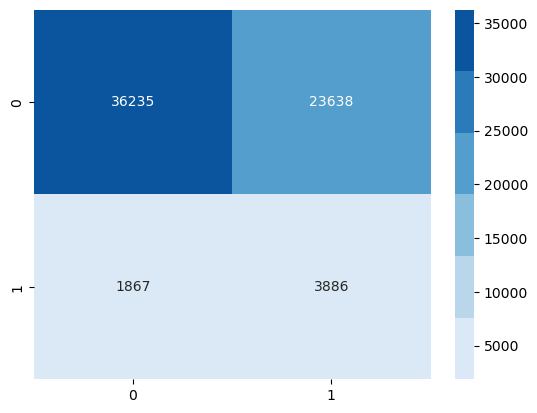

In [38]:
#the true y's
true = y_test[:,1]
#the predicted y's
pred = y_pred

import seaborn as sns
from sklearn.metrics import confusion_matrix
pred[pred < 0.5] = -1
pred[pred >= 0.5] = 1

#confusion matrix
cm = confusion_matrix(true,pred)
print(cm)

# Plot the confusion matrix with the custom colormap
sns.heatmap(cm, annot=True, fmt="d", cmap=sns.color_palette("Blues"))